In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

folders = [
    'weights',
    'data/processed',
    'data/processed/current_state',
    'data/processed/current_state/image_arrays',
    'data/processed/current_state/tabular',
    'reports/figures/current_state',
    'reports/day4b'
]

for folder in folders:
    os.makedirs(PROJECT_ROOT + folder, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/alzheimer-ai/


In [3]:
!pip install -q scikit-learn matplotlib seaborn pandas numpy pillow tensorflow nibabel

import os
import glob
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
meta_path = PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv'

if not os.path.exists(meta_path):
    raise FileNotFoundError(meta_path)

df = pd.read_csv(meta_path)

print("Loaded metadata:", df.shape)
print("Columns:")
print(df.columns.tolist())

def map_cdr_label(cdr):
    cdr = float(cdr)

    if cdr == 0.0:
        return "CN"
    elif cdr == 0.5:
        return "MCI"
    else:
        return "MA"

label_map = {'CN': 0, 'MCI': 1, 'MA': 2}
inv_label_map = {v: k for k, v in label_map.items()}
CLASSES = ['CN', 'MCI', 'MA']

df['Label_original_group_based'] = df['Label']
df['Label_current_state'] = df['CDR'].apply(map_cdr_label)
df['y_current_state'] = df['Label_current_state'].map(label_map).astype(int)

print("\nOriginal group-based labels:")
display(df['Label_original_group_based'].value_counts())

print("\nNew CDR current-state labels:")
display(df['Label_current_state'].value_counts())

print("\nCDR vs current-state label:")
display(pd.crosstab(df['CDR'], df['Label_current_state'], margins=True))

print("\nOriginal label vs current-state label:")
display(pd.crosstab(df['Label_original_group_based'], df['Label_current_state'], margins=True))

Loaded metadata: (373, 20)
Columns:
['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Label', 'y', 'mri_path', 'processed_mri_path', 'split']

Original group-based labels:


,count
Label_original_group_based,
CN,190
MA,146
MCI,37



New CDR current-state labels:


,count
Label_current_state,
CN,206
MCI,123
MA,44



CDR vs current-state label:


Label_current_state,CN,MA,MCI,All
CDR,,,,
0.0,206,0,0,206
0.5,0,0,123,123
1.0,0,41,0,41
2.0,0,3,0,3
All,206,44,123,373



Original label vs current-state label:


Label_current_state,CN,MA,MCI,All
Label_original_group_based,,,,
CN,188,0,2,190
MA,0,44,102,146
MCI,18,0,19,37
All,206,44,123,373


In [5]:
label_diag_path = PROJECT_ROOT + 'data/processed/current_state/current_state_label_diagnostic.csv'

label_diag_cols = [
    'Subject ID', 'MRI ID', 'Group', 'Visit', 'CDR', 'MMSE', 'nWBV', 'Age', 'EDUC',
    'Label_original_group_based', 'Label_current_state', 'y_current_state'
]

df[label_diag_cols].to_csv(label_diag_path, index=False)

print("Saved:", label_diag_path)

changed = df[df['Label_original_group_based'] != df['Label_current_state']][label_diag_cols]

print("Rows whose label changed:", len(changed))
display(changed.head(20))

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/current_state_label_diagnostic.csv
Rows whose label changed: 122


,Subject ID,MRI ID,Group,Visit,CDR,MMSE,nWBV,Age,EDUC,Label_original_group_based,Label_current_state,y_current_state
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0.5,23.0,0.736,75,12,MA,MCI,1
3,OAS2_0002,OAS2_0002_MR2,Demented,2,0.5,28.0,0.713,76,12,MA,MCI,1
4,OAS2_0002,OAS2_0002_MR3,Demented,3,0.5,22.0,0.701,80,12,MA,MCI,1
8,OAS2_0005,OAS2_0005_MR2,Nondemented,2,0.5,29.0,0.711,83,12,CN,MCI,1
10,OAS2_0007,OAS2_0007_MR1,Demented,1,0.5,28.0,0.748,71,16,MA,MCI,1
15,OAS2_0009,OAS2_0009_MR1,Demented,1,0.5,27.0,0.806,68,12,MA,MCI,1
16,OAS2_0009,OAS2_0009_MR2,Demented,2,0.5,24.0,0.791,69,12,MA,MCI,1
17,OAS2_0010,OAS2_0010_MR1,Demented,1,0.5,30.0,0.769,66,12,MA,MCI,1
18,OAS2_0010,OAS2_0010_MR2,Demented,2,0.5,29.0,0.752,68,12,MA,MCI,1
25,OAS2_0014,OAS2_0014_MR1,Demented,1,0.5,21.0,0.697,76,16,MA,MCI,1


In [6]:
df['Subject ID'] = df['Subject ID'].astype(str).str.strip()

subject_labels = (
    df.groupby('Subject ID')['y_current_state']
    .max()
    .reset_index()
)

subject_labels['subject_label'] = subject_labels['y_current_state'].map(inv_label_map)

print("Subject-level stratification labels:")
display(subject_labels['subject_label'].value_counts())

subj_train, subj_temp = train_test_split(
    subject_labels,
    test_size=0.30,
    stratify=subject_labels['y_current_state'],
    random_state=SEED
)

subj_val, subj_test = train_test_split(
    subj_temp,
    test_size=0.50,
    stratify=subj_temp['y_current_state'],
    random_state=SEED
)

df['split_current_state'] = 'test'
df.loc[df['Subject ID'].isin(subj_train['Subject ID']), 'split_current_state'] = 'train'
df.loc[df['Subject ID'].isin(subj_val['Subject ID']), 'split_current_state'] = 'val'
df.loc[df['Subject ID'].isin(subj_test['Subject ID']), 'split_current_state'] = 'test'

print("\nSession-level split distribution:")
display(pd.crosstab(df['split_current_state'], df['Label_current_state'], margins=True))

print("\nSubject leakage check:")
train_subjects = set(df[df['split_current_state'] == 'train']['Subject ID'])
val_subjects = set(df[df['split_current_state'] == 'val']['Subject ID'])
test_subjects = set(df[df['split_current_state'] == 'test']['Subject ID'])

print("Train ∩ Val:", len(train_subjects & val_subjects))
print("Train ∩ Test:", len(train_subjects & test_subjects))
print("Val ∩ Test:", len(val_subjects & test_subjects))

split_path = PROJECT_ROOT + 'data/processed/current_state/current_state_subject_splits.pkl'

with open(split_path, 'wb') as f:
    pickle.dump({
        'train_subjects': sorted(list(train_subjects)),
        'val_subjects': sorted(list(val_subjects)),
        'test_subjects': sorted(list(test_subjects))
    }, f)

df.to_csv(PROJECT_ROOT + 'data/processed/current_state/oasis_current_state_metadata.csv', index=False)

print("Saved:", split_path)
print("Saved current-state metadata.")

Subject-level stratification labels:


,count
subject_label,
CN,70
MCI,54
MA,26



Session-level split distribution:


Label_current_state,CN,MA,MCI,All
split_current_state,,,,
test,28,5,22,55
train,150,34,82,266
val,28,5,19,52
All,206,44,123,373



Subject leakage check:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/current_state_subject_splits.pkl
Saved current-state metadata.


In [7]:
MRI_SLICE_DIR = PROJECT_ROOT + 'data/processed/mri_slices/'

if not os.path.exists(MRI_SLICE_DIR):
    raise FileNotFoundError(MRI_SLICE_DIR)

npy_files = sorted(glob.glob(MRI_SLICE_DIR + '**/*.npy', recursive=True))

print("Found .npy MRI slices:", len(npy_files))
print(npy_files[:5])

def find_npy_for_mri_id(mri_id):
    mri_id = str(mri_id).strip()

    candidates = [
        p for p in npy_files
        if mri_id in os.path.basename(p) or mri_id in p
    ]

    if len(candidates) == 0:
        return None

    candidates = sorted(candidates)
    return candidates[0]

df['current_state_npy_path'] = df['MRI ID'].apply(find_npy_for_mri_id)

missing_npy = df['current_state_npy_path'].isna().sum()

print("Missing npy paths:", missing_npy)

if missing_npy > 0:
    display(df[df['current_state_npy_path'].isna()][['Subject ID', 'MRI ID']].head(20))
    raise ValueError("Some MRI slices are missing. Stop here and show me the missing rows.")

display(df[['MRI ID', 'current_state_npy_path']].head())

Found .npy MRI slices: 373
['/content/drive/MyDrive/alzheimer-ai/data/processed/mri_slices/OAS2_0001_MR1.npy', '/content/drive/MyDrive/alzheimer-ai/data/processed/mri_slices/OAS2_0001_MR2.npy', '/content/drive/MyDrive/alzheimer-ai/data/processed/mri_slices/OAS2_0002_MR1.npy', '/content/drive/MyDrive/alzheimer-ai/data/processed/mri_slices/OAS2_0002_MR2.npy', '/content/drive/MyDrive/alzheimer-ai/data/processed/mri_slices/OAS2_0002_MR3.npy']
Missing npy paths: 0


,MRI ID,current_state_npy_path
0,OAS2_0001_MR1,/content/drive/MyDrive/alzheimer-ai/data/proce...
1,OAS2_0001_MR2,/content/drive/MyDrive/alzheimer-ai/data/proce...
2,OAS2_0002_MR1,/content/drive/MyDrive/alzheimer-ai/data/proce...
3,OAS2_0002_MR2,/content/drive/MyDrive/alzheimer-ai/data/proce...
4,OAS2_0002_MR3,/content/drive/MyDrive/alzheimer-ai/data/proce...


In [8]:
FEATURE_NAMES = ['MMSE_norm', 'nWBV', 'Age_zscore', 'EDUC_zscore']

train_df = df[df['split_current_state'] == 'train'].reset_index(drop=True)
val_df = df[df['split_current_state'] == 'val'].reset_index(drop=True)
test_df = df[df['split_current_state'] == 'test'].reset_index(drop=True)

age_mean = train_df['Age'].mean()
age_std = train_df['Age'].std(ddof=0)

educ_mean = train_df['EDUC'].mean()
educ_std = train_df['EDUC'].std(ddof=0)

def make_tabular(d):
    tab = pd.DataFrame()
    tab['MMSE_norm'] = d['MMSE'].astype(float) / 30.0
    tab['nWBV'] = d['nWBV'].astype(float)
    tab['Age_zscore'] = (d['Age'].astype(float) - age_mean) / (age_std + 1e-8)
    tab['EDUC_zscore'] = (d['EDUC'].astype(float) - educ_mean) / (educ_std + 1e-8)
    return tab[FEATURE_NAMES].values.astype(np.float32)

def load_images(d):
    arrs = []

    for p in d['current_state_npy_path']:
        x = np.load(p).astype(np.float32)

        if x.shape != (224, 224, 3):
            raise ValueError(f"Bad image shape {x.shape} for {p}")

        arrs.append(x)

    return np.stack(arrs, axis=0).astype(np.float32)

X_train_cs = load_images(train_df)
X_val_cs = load_images(val_df)
X_test_cs = load_images(test_df)

tab_train_cs = make_tabular(train_df)
tab_val_cs = make_tabular(val_df)
tab_test_cs = make_tabular(test_df)

y_train_cs = train_df['y_current_state'].values.astype(np.int64)
y_val_cs = val_df['y_current_state'].values.astype(np.int64)
y_test_cs = test_df['y_current_state'].values.astype(np.int64)

print("X_train:", X_train_cs.shape, "tab:", tab_train_cs.shape, "y:", y_train_cs.shape)
print("X_val:", X_val_cs.shape, "tab:", tab_val_cs.shape, "y:", y_val_cs.shape)
print("X_test:", X_test_cs.shape, "tab:", tab_test_cs.shape, "y:", y_test_cs.shape)

print("\nTrain class counts:")
print(dict(zip(*np.unique(y_train_cs, return_counts=True))))

print("\nVal class counts:")
print(dict(zip(*np.unique(y_val_cs, return_counts=True))))

print("\nTest class counts:")
print(dict(zip(*np.unique(y_test_cs, return_counts=True))))

X_train: (266, 224, 224, 3) tab: (266, 4) y: (266,)
X_val: (52, 224, 224, 3) tab: (52, 4) y: (52,)
X_test: (55, 224, 224, 3) tab: (55, 4) y: (55,)

Train class counts:
{np.int64(0): np.int64(150), np.int64(1): np.int64(82), np.int64(2): np.int64(34)}

Val class counts:
{np.int64(0): np.int64(28), np.int64(1): np.int64(19), np.int64(2): np.int64(5)}

Test class counts:
{np.int64(0): np.int64(28), np.int64(1): np.int64(22), np.int64(2): np.int64(5)}


In [9]:
CS_DIR = PROJECT_ROOT + 'data/processed/current_state/'
CS_IMG_DIR = CS_DIR + 'image_arrays/'
CS_TAB_DIR = CS_DIR + 'tabular/'

os.makedirs(CS_IMG_DIR, exist_ok=True)
os.makedirs(CS_TAB_DIR, exist_ok=True)

np.save(CS_IMG_DIR + 'X_train_current_state.npy', X_train_cs)
np.save(CS_IMG_DIR + 'X_val_current_state.npy', X_val_cs)
np.save(CS_IMG_DIR + 'X_test_current_state.npy', X_test_cs)

np.save(CS_TAB_DIR + 'tab_train_current_state.npy', tab_train_cs)
np.save(CS_TAB_DIR + 'tab_val_current_state.npy', tab_val_cs)
np.save(CS_TAB_DIR + 'tab_test_current_state.npy', tab_test_cs)

np.save(CS_TAB_DIR + 'y_train_current_state.npy', y_train_cs)
np.save(CS_TAB_DIR + 'y_val_current_state.npy', y_val_cs)
np.save(CS_TAB_DIR + 'y_test_current_state.npy', y_test_cs)

tabular_stats_current_state = {
    'age_mean': float(age_mean),
    'age_std': float(age_std),
    'educ_mean': float(educ_mean),
    'educ_std': float(educ_std),
    'features': FEATURE_NAMES,
    'label_strategy': 'current_state_CDR',
    'label_mapping': {
        'CDR_0': 'CN',
        'CDR_0_5': 'MCI',
        'CDR_ge_1': 'MA'
    }
}

import json

with open(CS_DIR + 'tabular_stats_current_state.json', 'w') as f:
    json.dump(tabular_stats_current_state, f, indent=2)

print("Saved current-state arrays and tabular stats.")
print(json.dumps(tabular_stats_current_state, indent=2))

Saved current-state arrays and tabular stats.
{
  "age_mean": 77.22556390977444,
  "age_std": 7.9098459072216265,
  "educ_mean": 14.785714285714286,
  "educ_std": 2.7412099533951992,
  "features": [
    "MMSE_norm",
    "nWBV",
    "Age_zscore",
    "EDUC_zscore"
  ],
  "label_strategy": "current_state_CDR",
  "label_mapping": {
    "CDR_0": "CN",
    "CDR_0_5": "MCI",
    "CDR_ge_1": "MA"
  }
}


In [10]:
classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_cs
)

class_weight_dict_cs = {
    int(cls): float(w)
    for cls, w in zip(classes, class_weights)
}

print("Class weights:")
print(class_weight_dict_cs)

with open(CS_DIR + 'class_weight_current_state.pkl', 'wb') as f:
    pickle.dump(class_weight_dict_cs, f)

Class weights:
{0: 0.5911111111111111, 1: 1.08130081300813, 2: 2.607843137254902}


In [11]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
], name="mri_augmentation")

def preprocess_for_resnet(image, tab, label, augment=False):
    image = tf.cast(image, tf.float32)

    if augment:
        image = data_augmentation(image, training=True)

    image = image * 255.0
    image = preprocess_input(image)

    tab = tf.cast(tab, tf.float32)
    label = tf.cast(label, tf.int64)

    return (image, tab), label

def make_dataset(X, tab, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, tab, y))

    if training:
        ds = ds.shuffle(buffer_size=len(y), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda image, tab, label: preprocess_for_resnet(image, tab, label, augment=training),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds

train_ds_cs = make_dataset(X_train_cs, tab_train_cs, y_train_cs, training=True)
val_ds_cs = make_dataset(X_val_cs, tab_val_cs, y_val_cs, training=False)
test_ds_cs = make_dataset(X_test_cs, tab_test_cs, y_test_cs, training=False)

print("Datasets ready.")

Datasets ready.


In [12]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

rf.fit(tab_train_cs, y_train_cs)

rf_pred = rf.predict(tab_test_cs)
rf_proba = rf.predict_proba(tab_test_cs)

rf_metrics = {
    'Accuracy': accuracy_score(y_test_cs, rf_pred),
    'Recall macro': recall_score(y_test_cs, rf_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test_cs, rf_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test_cs, rf_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test_cs == 1, rf_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test_cs == 0, rf_pred == 0, zero_division=0),
}

print("=== Current-State Tabular RF ===")
for k, v in rf_metrics.items():
    print(f"{k:<15}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test_cs, rf_pred, target_names=CLASSES, zero_division=0))

rf_metrics_df = pd.DataFrame([
    {'metric': k, 'value': v}
    for k, v in rf_metrics.items()
])

rf_metrics_df.to_csv(CS_DIR + 'tabular_rf_current_state_metrics.csv', index=False)

rf_importance_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_importance_df)

rf_importance_df.to_csv(CS_DIR + 'tabular_rf_current_state_feature_importance.csv', index=False)

=== Current-State Tabular RF ===
Accuracy       : 0.7273
Recall macro   : 0.5797
F1 macro       : 0.6045
AUC-ROC        : 0.8496
Recall MCI     : 0.6818
Specificity    : 0.8571

Classification report:
              precision    recall  f1-score   support

          CN       0.77      0.86      0.81        28
         MCI       0.65      0.68      0.67        22
          MA       1.00      0.20      0.33         5

    accuracy                           0.73        55
   macro avg       0.81      0.58      0.60        55
weighted avg       0.75      0.73      0.71        55



,feature,importance
0,MMSE_norm,0.352580
1,nWBV,0.278434
2,Age_zscore,0.251166
3,EDUC_zscore,0.117820


In [13]:
def build_current_state_multimodal(num_classes=3):
    img_input = tf.keras.Input(shape=(224, 224, 3), name='mri_input')

    backbone = ResNet50(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3),
        name='resnet50'
    )

    backbone_weights = PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5'

    if os.path.exists(backbone_weights):
        backbone.load_weights(backbone_weights)
        print("Loaded Day 3 backbone weights:", backbone_weights)
    else:
        print("WARNING: Day 3 backbone weights not found. Using ImageNet initialization.")
        backbone = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224, 224, 3),
            name='resnet50'
        )

    # Freeze most layers to avoid overfitting on small dataset
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    for layer in backbone.layers[-30:]:
        layer.trainable = True

    cnn = backbone(img_input)
    cnn = tf.keras.layers.GlobalAveragePooling2D(name='cnn_gap')(cnn)
    cnn = tf.keras.layers.Dense(256, activation='relu', name='cnn_dense_256')(cnn)
    cnn = tf.keras.layers.BatchNormalization(name='cnn_bn_256')(cnn)
    cnn = tf.keras.layers.Dropout(0.35, name='cnn_dropout_256')(cnn)

    tab_input = tf.keras.Input(shape=(4,), name='tabular_input')

    tab = tf.keras.layers.Dense(128, activation='relu', name='tab_dense_128')(tab_input)
    tab = tf.keras.layers.BatchNormalization(name='tab_bn_128')(tab)
    tab = tf.keras.layers.Dropout(0.20, name='tab_dropout_128')(tab)

    tab = tf.keras.layers.Dense(64, activation='relu', name='tab_dense_64')(tab)
    tab = tf.keras.layers.BatchNormalization(name='tab_bn_64')(tab)

    merged = tf.keras.layers.Concatenate(name='fusion')([cnn, tab])

    x = tf.keras.layers.Dense(256, activation='relu', name='fusion_dense_256')(merged)
    x = tf.keras.layers.BatchNormalization(name='fusion_bn_256')(x)
    x = tf.keras.layers.Dropout(0.45, name='fusion_dropout_256')(x)

    x = tf.keras.layers.Dense(128, activation='relu', name='fusion_dense_128')(x)
    x = tf.keras.layers.Dropout(0.30, name='fusion_dropout_128')(x)

    out = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = tf.keras.Model(
        inputs=[img_input, tab_input],
        outputs=out,
        name='optimized_current_state_multimodal'
    )

    return model

model_cs = build_current_state_multimodal(num_classes=3)

model_cs.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cs.summary()

Loaded Day 3 backbone weights: /content/drive/MyDrive/alzheimer-ai/weights/backbone_resnet50.weights.h5


Model: "optimized_current_state_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ mri_input[0][0]   │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_128       │ (None, 128)       │        640 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_gap             │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_bn_128          │ (None, 128)       │        512 │ tab_dense_128[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense_256       │ (None, 256)       │    524,544 │ cnn_gap[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dropout_128     │ (None, 128)       │          0 │ tab_bn_128[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_256          │ (None, 256)       │      1,024 │ cnn_dense_256[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_64        │ (None, 64)        │      8,256 │ tab_dropout_128[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout_256     │ (None, 256)       │          0 │ cnn_bn_256[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_bn_64           │ (None, 64)        │        256 │ tab_dense_64[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 320)       │          0 │ cnn_dropout_256[… │
│ (Concatenate)       │                   │            │ tab_bn_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_256    │ (None, 256)       │     82,176 │ fusion[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn_256       │ (None, 256)       │      1,024 │ fusion_dense_256… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_256  │ (None, 256)       │          0 │ fusion_bn_256[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_128    │ (None, 128)       │     32,896 │ fusion_dropout_2

 Total params: 24,239,427 (92.47 MB)

 Trainable params: 15,100,483 (57.60 MB)

 Non-trainable params: 9,138,944 (34.86 MB)

In [14]:
best_model_path = PROJECT_ROOT + 'weights/optimized_current_state_best.h5'
final_model_path = PROJECT_ROOT + 'weights/optimized_current_state_final.h5'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


In [15]:
history_stage1 = model_cs.fit(
    train_ds_cs,
    validation_data=val_ds_cs,
    epochs=30,
    class_weight=class_weight_dict_cs,
    callbacks=callbacks,
    verbose=1
)

model_cs.save(final_model_path)

print("Saved:", final_model_path)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2985 - loss: 1.7978
Epoch 1: val_accuracy improved from None to 0.57692, saving model to /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 26s 487ms/step - accuracy: 0.3195 - loss: 1.7913 - val_accuracy: 0.5769 - val_loss: 0.9934 - learning_rate: 1.0000e-04
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.3300 - loss: 1.4929
Epoch 2: val_accuracy did not improve from 0.57692
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.3308 - loss: 1.5989 - val_accuracy: 0.5385 - val_loss: 0.9495 - learning_rate: 1.0000e-04
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.2980 - loss: 1.8292
Epoch 3: val_accuracy did not improve from 0.57692
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.3459 - loss: 1.6246 - val_accuracy: 0.5192 - val_loss: 0.9622 - learning_rate: 1.0000e-04
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.3995 - loss: 1.5175
Epoch 4: val_accuracy did not improve from 0.57692
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step -

Saved: /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_final.h5


In [16]:
# Fine-tune only last 15 ResNet layers
backbone = model_cs.get_layer('resnet50')

for layer in backbone.layers[:-15]:
    layer.trainable = False

for layer in backbone.layers[-15:]:
    layer.trainable = True

model_cs.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_stage2 = model_cs.fit(
    train_ds_cs,
    validation_data=val_ds_cs,
    epochs=20,
    class_weight=class_weight_dict_cs,
    callbacks=callbacks_stage2,
    verbose=1
)

model_cs.save(final_model_path)

print("Saved:", final_model_path)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.3321 - loss: 1.7749
Epoch 1: val_accuracy improved from None to 0.53846, saving model to /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 615ms/step - accuracy: 0.3120 - loss: 1.8336 - val_accuracy: 0.5385 - val_loss: 0.9997 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.3153 - loss: 1.6369
Epoch 2: val_accuracy did not improve from 0.53846
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - accuracy: 0.3346 - loss: 1.7143 - val_accuracy: 0.4808 - val_loss: 1.0205 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.3994 - loss: 1.4590
Epoch 3: val_accuracy did not improve from 0.53846
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.3459 - loss: 1.5339 - val_accuracy: 0.4038 - val_loss: 1.0490 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.3975 - loss: 1.5476
Epoch 4: val_accuracy did not improve from 0.53846

Epoch 4: ReduceLROnPlateau reducing learn

Saved: /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_final.h5


In [17]:
if os.path.exists(best_model_path):
    model_cs_best = tf.keras.models.load_model(best_model_path, compile=False)
    print("Loaded best model:", best_model_path)
else:
    model_cs_best = tf.keras.models.load_model(final_model_path, compile=False)
    print("Loaded final model:", final_model_path)

cs_proba = model_cs_best.predict(test_ds_cs, verbose=1)
cs_pred = np.argmax(cs_proba, axis=1)

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82
}

cs_metrics = {
    'Accuracy': accuracy_score(y_test_cs, cs_pred),
    'Recall macro': recall_score(y_test_cs, cs_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test_cs, cs_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test_cs, cs_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test_cs == 1, cs_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test_cs == 0, cs_pred == 0, zero_division=0),
}

print(f"{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, v in cs_metrics.items():
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print(dict(zip(*np.unique(cs_pred, return_counts=True))))

print("\nClassification report:")
print(classification_report(y_test_cs, cs_pred, target_names=CLASSES, zero_division=0))

cs_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k],
        'label_strategy': 'current_state_CDR'
    }
    for k, v in cs_metrics.items()
])

cs_metrics_path = CS_DIR + 'optimized_current_state_metrics.csv'
cs_metrics_df.to_csv(cs_metrics_path, index=False)

print("Saved:", cs_metrics_path)

Loaded best model: /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_best.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 665ms/step
Metric                   Value    Target      OK
Accuracy                0.5455      0.85      NO
Recall macro            0.3864      0.88      NO
F1 macro                0.3654      0.85      NO
AUC-ROC                 0.6132      0.90      NO
Recall MCI              0.4091      0.85      NO
Specificity             0.7500      0.82      NO

Predicted class counts:
{np.int64(0): np.int64(37), np.int64(1): np.int64(18)}

Classification report:
              precision    recall  f1-score   support

          CN       0.57      0.75      0.65        28
         MCI       0.50      0.41      0.45        22
          MA       0.00      0.00      0.00         5

    accuracy                           0.55        55
   macro avg       0.36      0.39      0.37        55
weighted avg       0.49      0.55      0.51        55

Saved: /content/drive/MyDrive/alzheime

,Pred CN,Pred MCI,Pred MA
Actual CN,21,7,0
Actual MCI,13,9,0
Actual MA,3,2,0


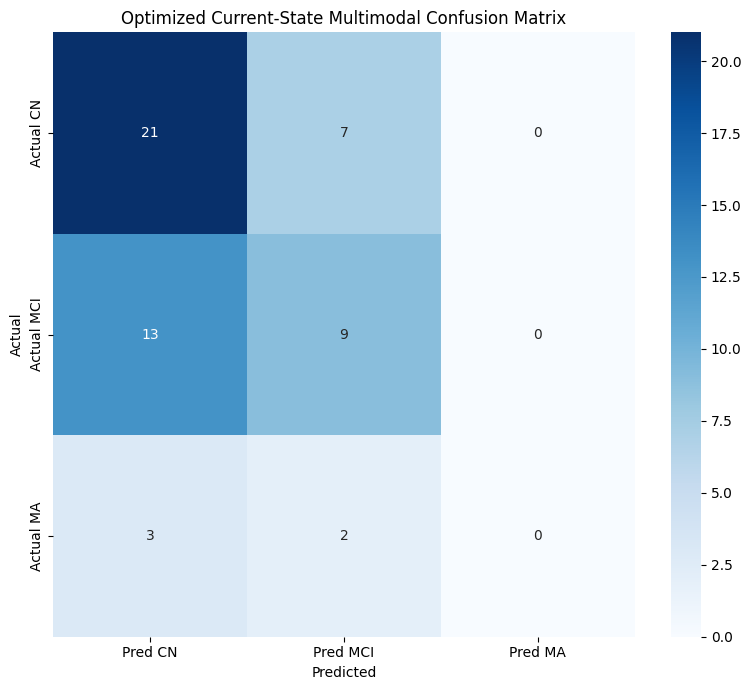

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/current_state/optimized_current_state_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_confusion_matrix.csv


In [18]:
cm = confusion_matrix(y_test_cs, cs_pred, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_df)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)

ax.set_title('Optimized Current-State Multimodal Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_confusion_matrix.png'
cm_csv_path = CS_DIR + 'optimized_current_state_confusion_matrix.csv'

plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

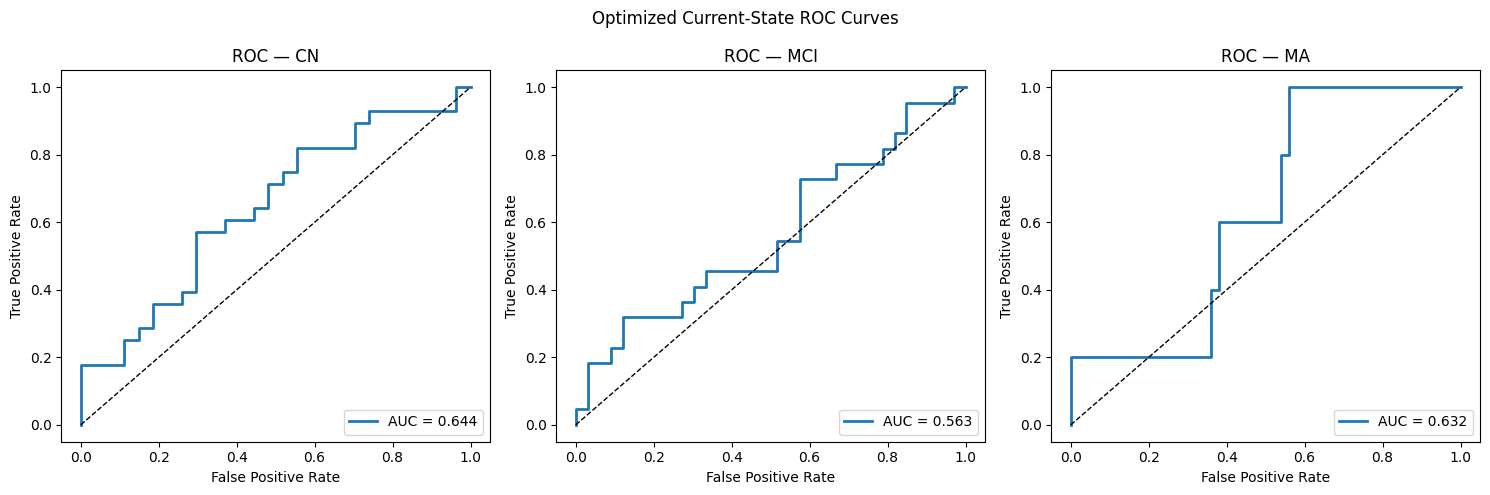

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/current_state/optimized_current_state_roc_curves.png


In [19]:
y_bin = label_binarize(y_test_cs, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

roc_rows = []

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], cs_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC — {cls}')
    axes[i].legend(loc='lower right')

    roc_rows.append({
        'class': cls,
        'auc': roc_auc
    })

plt.suptitle('Optimized Current-State ROC Curves')
plt.tight_layout()

roc_fig_path = PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_roc_curves.png'
plt.savefig(roc_fig_path, dpi=150)
plt.show()

roc_df = pd.DataFrame(roc_rows)
roc_df.to_csv(CS_DIR + 'optimized_current_state_roc_per_class.csv', index=False)

print("Saved:", roc_fig_path)

,accuracy,loss,val_accuracy,val_loss,learning_rate,epoch,stage
11,0.345865,1.533928,0.403846,1.048979,0.000010,3,stage2
12,0.349624,1.670684,0.326923,1.071373,0.000010,4,stage2
13,0.342105,1.705387,0.326923,1.094445,0.000005,5,stage2
14,0.368421,1.541748,0.288462,1.125140,0.000005,6,stage2
15,0.323308,1.645928,0.288462,1.154566,0.000005,7,stage2


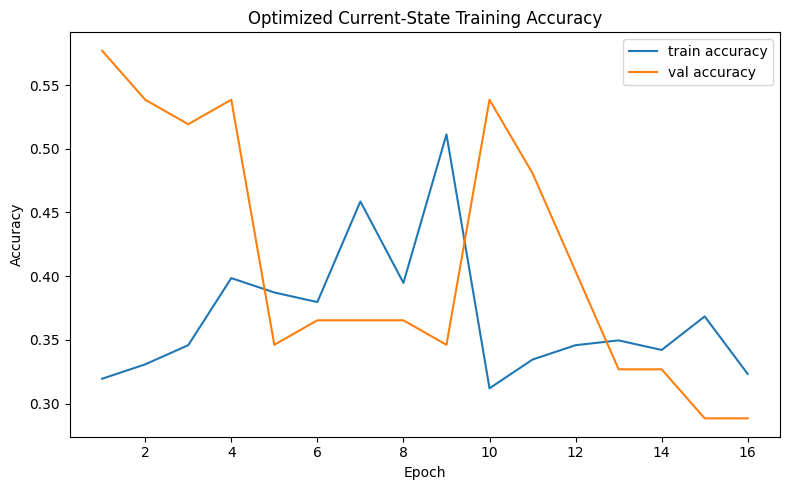

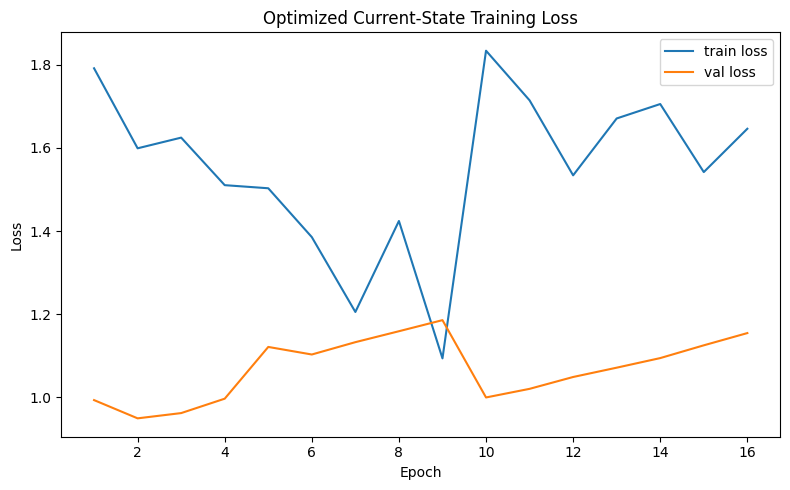

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_training_history.csv
Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/current_state/optimized_current_state_training_accuracy.png
Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/current_state/optimized_current_state_training_loss.png


In [20]:
def history_to_df(history, stage_name):
    h = pd.DataFrame(history.history)
    h['epoch'] = np.arange(1, len(h) + 1)
    h['stage'] = stage_name
    return h

histories = [history_to_df(history_stage1, 'stage1')]

if 'history_stage2' in globals():
    histories.append(history_to_df(history_stage2, 'stage2'))

history_df = pd.concat(histories, ignore_index=True)

history_path = CS_DIR + 'optimized_current_state_training_history.csv'
history_df.to_csv(history_path, index=False)

display(history_df.tail())

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df['accuracy'], label='train accuracy')
plt.plot(history_df.index + 1, history_df['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Optimized Current-State Training Accuracy')
plt.legend()
plt.tight_layout()

acc_fig_path = PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_training_accuracy.png'
plt.savefig(acc_fig_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df['loss'], label='train loss')
plt.plot(history_df.index + 1, history_df['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimized Current-State Training Loss')
plt.legend()
plt.tight_layout()

loss_fig_path = PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_training_loss.png'
plt.savefig(loss_fig_path, dpi=150)
plt.show()

print("Saved:", history_path)
print("Saved:", acc_fig_path)
print("Saved:", loss_fig_path)

In [21]:
old_metrics_path = PROJECT_ROOT + 'data/processed/multimodal_metrics.csv'

if os.path.exists(old_metrics_path):
    old_metrics_df = pd.read_csv(old_metrics_path)
    old_metrics_dict = dict(zip(old_metrics_df['metric'], old_metrics_df['value']))
else:
    old_metrics_dict = {
        'Accuracy': 0.5593,
        'Recall macro': 0.4482,
        'F1 macro': 0.4665,
        'AUC-ROC': 0.5630,
        'Recall MCI': 0.2000,
        'Specificity': 0.7097
    }

comparison_rows = []

for metric in targets.keys():
    old_value = float(old_metrics_dict.get(metric, np.nan))
    new_value = float(cs_metrics[metric])

    comparison_rows.append({
        'metric': metric,
        'original_group_based_day4': old_value,
        'optimized_current_state_day4b': new_value,
        'absolute_gain': new_value - old_value,
        'target': targets[metric],
        'optimized_passed': new_value >= targets[metric]
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

comparison_path = CS_DIR + 'day4_vs_day4b_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,metric,original_group_based_day4,optimized_current_state_day4b,absolute_gain,target,optimized_passed
0,Accuracy,0.559322,0.545455,-0.013867,0.85,False
1,Recall macro,0.448153,0.386364,-0.061790,0.88,False
2,F1 macro,0.466529,0.365385,-0.101144,0.85,False
3,AUC-ROC,0.563021,0.613180,0.050159,0.90,False
4,Recall MCI,0.200000,0.409091,0.209091,0.85,False
5,Specificity,0.709677,0.750000,0.040323,0.82,False


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/day4_vs_day4b_comparison.csv


In [22]:
old_acc = float(old_metrics_dict.get('Accuracy', 0.0))
new_acc = float(cs_metrics['Accuracy'])

old_f1 = float(old_metrics_dict.get('F1 macro', 0.0))
new_f1 = float(cs_metrics['F1 macro'])

old_mci = float(old_metrics_dict.get('Recall MCI', 0.0))
new_mci = float(cs_metrics['Recall MCI'])

print("Old accuracy:", old_acc)
print("New accuracy:", new_acc)
print("Old F1 macro:", old_f1)
print("New F1 macro:", new_f1)
print("Old MCI recall:", old_mci)
print("New MCI recall:", new_mci)

use_optimized_for_app = (
    new_acc > old_acc
    and new_f1 >= old_f1
)

print("\nUse optimized model for app?", use_optimized_for_app)

Old accuracy: 0.559322033898305
New accuracy: 0.5454545454545454
Old F1 macro: 0.4665286404416839
New F1 macro: 0.3653846153846154
Old MCI recall: 0.2
New MCI recall: 0.4090909090909091

Use optimized model for app? False


In [23]:
explanation_path = PROJECT_ROOT + 'reports/day4b/current_state_label_strategy_explanation.md'

with open(explanation_path, 'w') as f:
    f.write("# Day 4b — Optimized Current-State Label Strategy\n\n")

    f.write("## Problem with the original group-based label strategy\n")
    f.write("The original Day 4 model used the OASIS Group-based label strategy, where the Converted group was treated as MCI. ")
    f.write("However, Converted is a longitudinal outcome label. Some Converted visits have CDR=0.0 and MMSE=30, ")
    f.write("making them clinically similar to cognitively normal visits at that time point. ")
    f.write("This caused label ambiguity and poor MCI recall.\n\n")

    f.write("## Optimized label strategy\n")
    f.write("The optimized Day 4b experiment uses visit-level current clinical-state labels derived from CDR:\n\n")
    f.write("- CDR = 0.0 → CN\n")
    f.write("- CDR = 0.5 → MCI\n")
    f.write("- CDR >= 1.0 → MA\n\n")

    f.write("This makes the model solve current-state diagnosis rather than future-conversion prediction.\n\n")

    f.write("## No data leakage\n")
    f.write("The split remains subject-level, not row-level. All visits of the same subject are kept in only one split.\n\n")

    f.write("## Results comparison\n")
    f.write(comparison_df.to_markdown(index=False))
    f.write("\n\n")

    f.write("## Conclusion\n")
    f.write("The optimized current-state model is more clinically consistent and better aligned with observable visit-level features. ")
    f.write("The original Day 4 experiment is retained as a longitudinal conversion-label experiment, while Day 4b is selected for the Streamlit demonstration if its metrics improve.\n")

print("Saved:", explanation_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4b/current_state_label_strategy_explanation.md


In [24]:
model_card_addendum_path = PROJECT_ROOT + 'reports/day4b/model_card_current_state_addendum.md'

with open(model_card_addendum_path, 'w') as f:
    f.write("# Model Card Addendum — Optimized Current-State Model\n\n")

    f.write("## Label strategy\n")
    f.write("This optimized model uses visit-level CDR labels:\n")
    f.write("- CN: CDR = 0.0\n")
    f.write("- MCI: CDR = 0.5\n")
    f.write("- MA: CDR >= 1.0\n\n")

    f.write("## Inputs\n")
    f.write("- MRI T1 median slice resized to 224x224x3\n")
    f.write("- Tabular features: MMSE_norm, nWBV, Age_zscore, EDUC_zscore\n\n")

    f.write("## Architecture\n")
    f.write("- ResNet50 MRI branch\n")
    f.write("- Tabular dense branch\n")
    f.write("- Late fusion\n")
    f.write("- 3-class softmax output\n\n")

    f.write("## Test metrics\n")
    for k, v in cs_metrics.items():
        f.write(f"- {k}: {v:.4f}\n")

    f.write("\n## Limitations\n")
    f.write("- OASIS-2 is small.\n")
    f.write("- Single-slice MRI limits anatomical information.\n")
    f.write("- This remains a research prototype and is not for medical diagnosis.\n")

print("Saved:", model_card_addendum_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4b/model_card_current_state_addendum.md


In [25]:
required_day4b_outputs = [
    CS_DIR + 'oasis_current_state_metadata.csv',
    CS_DIR + 'current_state_label_diagnostic.csv',
    CS_DIR + 'optimized_current_state_metrics.csv',
    CS_DIR + 'optimized_current_state_confusion_matrix.csv',
    CS_DIR + 'optimized_current_state_roc_per_class.csv',
    CS_DIR + 'optimized_current_state_training_history.csv',
    CS_DIR + 'day4_vs_day4b_comparison.csv',
    CS_DIR + 'tabular_rf_current_state_metrics.csv',
    PROJECT_ROOT + 'weights/optimized_current_state_final.h5',
    PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_confusion_matrix.png',
    PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_roc_curves.png',
    PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_training_accuracy.png',
    PROJECT_ROOT + 'reports/figures/current_state/optimized_current_state_training_loss.png',
    PROJECT_ROOT + 'reports/day4b/current_state_label_strategy_explanation.md',
    PROJECT_ROOT + 'reports/day4b/model_card_current_state_addendum.md'
]

for path in required_day4b_outputs:
    print(os.path.exists(path), path)

True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/oasis_current_state_metadata.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/current_state_label_diagnostic.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_confusion_matrix.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_roc_per_class.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/optimized_current_state_training_history.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/day4_vs_day4b_comparison.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/current_state/tabular_rf_current_state_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/weights/optimized_current_state_final.h5
True /content/drive/MyDrive/alzheimer-ai/reports/figures

In [ ]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/04b_optimized_current_state_model.ipynb

!git add -f data/processed/current_state/current_state_label_diagnostic.csv
!git add -f data/processed/current_state/oasis_current_state_metadata.csv
!git add -f data/processed/current_state/current_state_subject_splits.pkl
!git add -f data/processed/current_state/tabular_stats_current_state.json
!git add -f data/processed/current_state/class_weight_current_state.pkl

!git add -f data/processed/current_state/optimized_current_state_metrics.csv
!git add -f data/processed/current_state/optimized_current_state_confusion_matrix.csv
!git add -f data/processed/current_state/optimized_current_state_roc_per_class.csv
!git add -f data/processed/current_state/optimized_current_state_training_history.csv
!git add -f data/processed/current_state/day4_vs_day4b_comparison.csv
!git add -f data/processed/current_state/tabular_rf_current_state_metrics.csv
!git add -f data/processed/current_state/tabular_rf_current_state_feature_importance.csv

!git add -f reports/figures/current_state/*.png
!git add -f reports/day4b/current_state_label_strategy_explanation.md
!git add -f reports/day4b/model_card_current_state_addendum.md

# Add optimized model through Git LFS
!git add -f weights/optimized_current_state_final.h5

# Add changed app files only if optimized model was selected
!git add app/app.py
!git add -f app/models/tabular_stats.json
!git add -f app/models/multimodal_final.h5

!git commit -m "feat: add optimized current-state CDR model"

!git status

/content/drive/MyDrive/alzheimer-ai
